In [45]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

### 1. Setting up Configurations

In [46]:
RAW_DATA_PATH = Path('../../data/raw/Telco-Customer-Churn.csv')
PROCESSED_DATA_PATH = Path('../../data/processed')
ARTIFACTS_DIR = Path('../../artifacts')
FIGURE_DIR = Path('../../artifacts/figures')

### 2. Load Data

In [47]:
df = pd.read_csv(RAW_DATA_PATH)

In [48]:
df.head(5)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


### 3. Univariant Analysis

#### 3.1 Split Numerical and Categorical columns

In [49]:
df_columns = df.columns
df_columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [50]:
numerical_col = []
categorical_col = []

for col in df_columns:
    if df[col].dtype == 'object':
        categorical_col.append(col)
    else:
        numerical_col.append(col)

print(f"Numerical columns : {numerical_col}")
print(f"Categorical columns : {categorical_col}")

Numerical columns : ['SeniorCitizen', 'tenure', 'MonthlyCharges']
Categorical columns : ['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'TotalCharges', 'Churn']


#### 3.2 Numerical Features Analysis

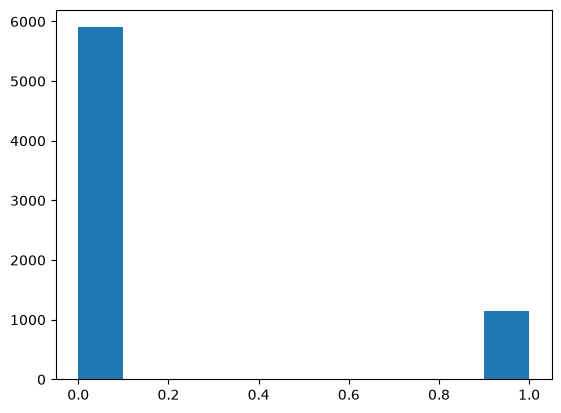

In [51]:
plt.hist(df['SeniorCitizen'])
plt.savefig(FIGURE_DIR / "eda_senior_citizen.png", dpi=150, bbox_inches='tight')

- The data type is int, but this is not actually continuous 

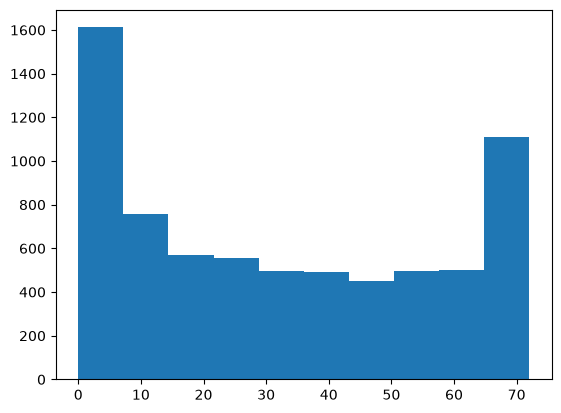

In [54]:
plt.hist(df['tenure'])
plt.savefig(FIGURE_DIR / "eda_tenure.png")

  - High spike at 0–5 months (1,600 customers) → early churn / onboarding risk
  - Flat middle band at 10–65 months (450–550 per bin) → stable retained customers
  - Late spike at 65–72 months (1,100 customers) → long-term loyal base

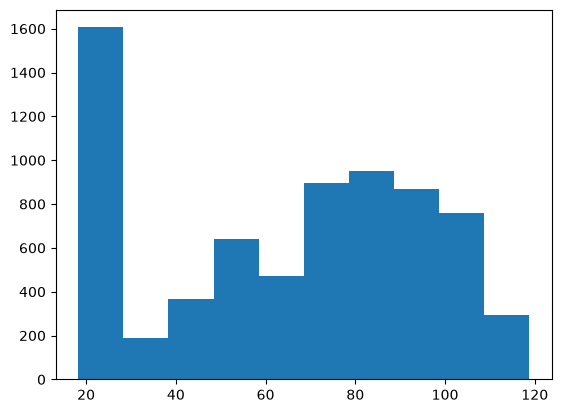

In [ ]:
plt.hist(df['MonthlyCharges'])
plt.savefig(FIGURE_DIR / "eda_monthly_charges.png")

- Large spike at $20–30 (1,600 customers) → low-tier/basic plan segment 
- Second peak at $80–90 (950 customers) → premium plan segment